# Notebook 03 — Modelling and Business Decision Layer

**Purpose.** Turn the descriptive findings of notebook 02 into a validated probability-of-default (PD) model over the 24-month observation window built in notebook 01, and translate the resulting PDs into a decision layer a credit committee could adopt.

**Inputs.** `data/processed/loans_2019_labeled.parquet` — the origination-only modelling table with the corrected `default_24m` target.

**Outputs.** Fitted baseline (logistic) and challenger (LightGBM) models; out-of-sample discrimination and calibration metrics; expected-loss cutoff simulation. Charts and small summary tables are saved to `figures/` for notebook 04 to consume.

**Non-goals.** Multi-vintage validation, macroeconomic overlays, an LGD model estimated from data — the LGD assumption is a literature value, disclosed in section 9.

## 0. Setup

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve,
)

import lightgbm as lgb

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
if (cwd / "pyproject.toml").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError(f"Could not resolve project root from {cwd}")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LOANS_FILE = DATA_PROCESSED / "loans_2019_labeled.parquet"
assert LOANS_FILE.exists(), f"Missing {LOANS_FILE}; run notebook 01 first"

SEED = 42

loans = pd.read_parquet(LOANS_FILE)

# Leakage guard: no post-origination diagnostics should ever enter modelling.
POST_ORIGINATION_COLUMNS = {
    "max_dpd_24m", "observation_months",
    "last_reporting_period_24m", "prepaid_within_24m",
}
leaked = POST_ORIGINATION_COLUMNS.intersection(loans.columns)
assert not leaked, f"Post-origination columns present in modelling table: {leaked}"
assert loans["loan_sequence_number"].is_unique

print(f"Modelling table: {loans.shape[0]:,} rows \u00d7 {loans.shape[1]} columns")
print(f"Default rate:    {loans['default_24m'].mean() * 100:.3f} %")
print(f"Defaults:        {int(loans['default_24m'].sum()):,}")
print(f"first_payment_date range: {int(loans['first_payment_date'].min())} \u2013 {int(loans['first_payment_date'].max())}")

Modelling table: 49,946 rows × 20 columns
Default rate:    4.589 %
Defaults:        2,292
first_payment_date range: 201902 – 202003


## 1. Modelling objectives and design decisions

**Target.** `default_24m` from notebook 01: a loan reaches 90+ DPD at least once during calendar months 0–24 of its observation window. Prevalence on the in-scope 2019 vintage is roughly 0.79 %. The target is a *recorded-delinquency* endpoint, not realized credit loss (section 8.1 of notebook 02).

**Feature scope.** Origination-time information only. Every variable used below is knowable at application: FICO, LTV, DTI, loan purpose, occupancy, channel, number of units, number of borrowers, first-time buyer flag, property type, and geography aggregated to census region. Post-origination diagnostics (`max_dpd_24m`, `observation_months`, `last_reporting_period_24m`, `prepaid_within_24m`) are excluded by construction and re-checked by the leakage guard in section 0.

**Split strategy.** Stratified random split on `default_24m` to preserve prevalence (train 70 % / test 30 %), with a stratified 5-fold cross-validation on the training set for model selection. The vintage is a single origination year, so a purely temporal split by `first_payment_date` would train on early-2019 loans and test on late-2019/early-2020 loans that are structurally closer to the COVID shock — it would measure sensitivity to the shock rather than model generalisation. Section 2 revisits this choice and reports the temporal split as a robustness view.

**Feature engineering.** Continuous drivers (FICO, LTV, DTI) are banded for the logistic baseline using the cutpoints validated in notebook 02 (§3.1–3.3), so the interpretable model reflects the descriptive structure surfaced in the EDA. The gradient-boosting challenger keeps the raw continuous values, since LightGBM handles non-linearities and native NaN natively. All banding, imputation, encoding, and interaction terms are fitted inside a scikit-learn pipeline on the training fold only, never on the full dataset.

**Primary metrics.** AUC and PR-AUC for discrimination, KS for score separation, Brier for accuracy of the predicted probability. Discrimination and calibration are reported both cross-validated on train and on the held-out test set. A calibration curve is plotted before and after isotonic calibration (section 8).

**COVID-affected label.** The 2019 vintage encountered the pandemic during its first 24 months. Notebook 02 §8.3 documents that CARES-Act forbearance suppresses recorded 90+ DPD flags for many borrowers who would otherwise have breached, so `default_24m` under-counts economic default. This notebook does **not** correct the label: the model is trained on the observed endpoint and its outputs are stated as *nominal* probabilities of a recorded 90+ DPD event, not as absolute economic default probabilities. The implication for the business decision layer is picked up in section 8 (calibration is nominal, not absolute) and section 9 (LGD assumption compensates only in expectation).

**Non-goals.** Extensive hyperparameter search, model stacking, and probabilistic macro overlays. The comparison logistic vs. LightGBM is scoped to answer one question: do the non-linearities and interactions surfaced in the EDA (§4.1–4.3) buy enough discrimination to justify the interpretability cost.

## 2. Train/test split

Stratified random split is the primary design (decision from section 1). A temporal split by `first_payment_date` is computed alongside as a robustness view: on a single-vintage 2019 book, the temporal split does not measure generalisation to a new origination era so much as sensitivity to the COVID shock's timing on the *observation* window. Both are reported; only the random split feeds the modelling sections that follow.

### 2.1 Primary split — stratified random

In [13]:
TARGET = "default_24m"
TEST_SIZE = 0.30

y = loans[TARGET].astype(int)
X = loans.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
)

split_summary = pd.DataFrame({
    "n_loans":       [len(y_train), len(y_test), len(y)],
    "n_defaults":    [int(y_train.sum()), int(y_test.sum()), int(y.sum())],
    "default_rate":  [y_train.mean(), y_test.mean(), y.mean()],
}, index=["train", "test", "full"])

print(split_summary.assign(
    n_loans=lambda d: d["n_loans"].map("{:,}".format),
    n_defaults=lambda d: d["n_defaults"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.3f} %".format),
))

# Sanity: stratification preserves prevalence to within 0.01 pp.
assert abs(y_train.mean() - y_test.mean()) < 1e-4, "Stratification drift"

      n_loans n_defaults default_rate
train  34,962      1,604      4.588 %
test   14,984        688      4.592 %
full   49,946      2,292      4.589 %


### 2.2 Robustness view — temporal split

Loans with `first_payment_date <= 201909` (originated roughly through August 2019) go into a hypothetical training window; the remainder acts as an out-of-time test set. This is not used to fit the main models, but the prevalence contrast is worth noting: the later cohort spends a larger share of its 24-month window inside the pandemic period, so any prevalence gap reflects timing of the observation, not a shift in underwriting.

In [14]:
TIME_CUTOFF = 201909

time_train_mask = loans["first_payment_date"] <= TIME_CUTOFF
time_test_mask  = ~time_train_mask

time_split_summary = pd.DataFrame({
    "n_loans":      [int(time_train_mask.sum()), int(time_test_mask.sum())],
    "n_defaults":   [int(loans.loc[time_train_mask, TARGET].sum()),
                     int(loans.loc[time_test_mask,  TARGET].sum())],
    "default_rate": [loans.loc[time_train_mask, TARGET].mean(),
                     loans.loc[time_test_mask,  TARGET].mean()],
    "fpd_min":      [int(loans.loc[time_train_mask, "first_payment_date"].min()),
                     int(loans.loc[time_test_mask,  "first_payment_date"].min())],
    "fpd_max":      [int(loans.loc[time_train_mask, "first_payment_date"].max()),
                     int(loans.loc[time_test_mask,  "first_payment_date"].max())],
}, index=["time_train", "time_test"])

print(time_split_summary.assign(
    n_loans=lambda d: d["n_loans"].map("{:,}".format),
    n_defaults=lambda d: d["n_defaults"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.3f} %".format),
))

# Kept as a diagnostic reference; not used to fit the main models.

           n_loans n_defaults default_rate  fpd_min  fpd_max
time_train  28,802      1,308      4.541 %   201902   201909
time_test   21,144        984      4.654 %   201910   202003


**Takeaway.** Stratification holds to within 0.4 bp on the random split — train and test prevalences (4.588 % vs 4.592 %) are indistinguishable from the sample-wide 4.589 %. The temporal split shows a modest 11-bp gap (4.541 % on Feb–Sep 2019 originations vs 4.654 % on Oct 2019–Mar 2020), which is smaller than one might have feared and confirms two things: (i) underwriting was stable across the vintage, and (ii) the additional COVID exposure of the later cohort's observation window shows up as a small tilt, not a regime break. The random split is the operating one for the modelling loop; the temporal split is retained only as a robustness reference for section 6.

## 3. Feature engineering

Two feature matrices are built from the same source columns. The logistic baseline consumes **banded** versions of the three main continuous drivers — bin edges are the ones validated in notebook 02 (§3.1–3.3) — so the interpretable model reflects the descriptive structure the EDA surfaced. The LightGBM challenger consumes **raw** continuous values, since it handles non-linearities and NaN natively.

Banding, derivation, and the FTB × LTV interaction are deterministic transforms (published cutpoints, not learned parameters), so they are applied to train and test alike without leakage. Imputation, when needed inside the logistic pipeline, is fitted on the training fold only via `ColumnTransformer` in section 4.

### 3.1 Continuous banding for the logistic baseline

In [15]:
# Bin edges validated in notebook 02 §3.1, §3.2, §3.3
FICO_BINS   = [-np.inf, 619, 659, 699, 739, 779, np.inf]
FICO_LABELS = ["<620", "620-659", "660-699", "700-739", "740-779", "780+"]

LTV_BINS   = [-np.inf, 60, 70, 80, 85, 90, 95, np.inf]
LTV_LABELS = ["<=60", "60-70", "70-80", "80-85", "85-90", "90-95", ">95"]

DTI_BINS   = [-np.inf, 30, 36, 43, 45, np.inf]
DTI_LABELS = ["<=30", "30-36", "36-43", "43-45", ">45"]

def band(series, bins, labels):
    """pd.cut with a 'Missing' category for NaN — deterministic transform."""
    banded = pd.cut(series, bins=bins, labels=labels)
    return banded.cat.add_categories("Missing").fillna("Missing")

# Sanity: apply to the full column and check every row lands in a band
for col, bins, labels in [
    ("credit_score", FICO_BINS, FICO_LABELS),
    ("ltv",          LTV_BINS,  LTV_LABELS),
    ("dti",          DTI_BINS,  DTI_LABELS),
]:
    b = band(loans[col], bins, labels)
    assert b.notna().all(), f"{col}: unbanded rows remain"
    print(f"{col:14s}  bands: {list(b.cat.categories)}")

credit_score    bands: ['<620', '620-659', '660-699', '700-739', '740-779', '780+', 'Missing']
ltv             bands: ['<=60', '60-70', '70-80', '80-85', '85-90', '90-95', '>95', 'Missing']
dti             bands: ['<=30', '30-36', '36-43', '43-45', '>45', 'Missing']


### 3.2 Derived categorical features

- `region_census`: state grouped into the four Census regions from notebook 02 §5.4. Cuts the 51-level `property_state` down to a stable four-level feature without losing the geographic gradient.
- `num_units_bin`: single-unit vs multi-unit. The 3- and 4-unit groups are small (§3.5) and pooling stabilises the estimate.
- `num_borrowers_bin`: one borrower vs two or more. Same rationale.
- `ftb_ltv_band`: joint categorical crossing FTB flag with LTV band, restricted to purchase loans. Non-purchase and unknown-FTB rows go to a shared "NA" level. This is the explicit interaction argued for in §3.6 and §9.1 of notebook 02.

In [16]:
CENSUS_REGIONS = {
    "Northeast": {"CT", "ME", "MA", "NH", "NJ", "NY", "PA", "RI", "VT"},
    "Midwest":   {"IL", "IN", "IA", "KS", "MI", "MN", "MO", "NE", "ND", "OH", "SD", "WI"},
    "South":     {"AL", "AR", "DE", "DC", "FL", "GA", "KY", "LA", "MD", "MS", "NC",
                  "OK", "SC", "TN", "TX", "VA", "WV"},
    "West":      {"AK", "AZ", "CA", "CO", "HI", "ID", "MT", "NV", "NM", "OR", "UT",
                  "WA", "WY"},
}
STATE_TO_REGION = {s: r for r, states in CENSUS_REGIONS.items() for s in states}

def build_derived(df: pd.DataFrame) -> pd.DataFrame:
    """Deterministic feature derivation. Applied identically to train and test."""
    out = pd.DataFrame(index=df.index)

    # Continuous bands (for the logistic baseline)
    out["fico_band"] = band(df["credit_score"], FICO_BINS, FICO_LABELS)
    out["ltv_band"]  = band(df["ltv"],          LTV_BINS,  LTV_LABELS)
    out["dti_band"]  = band(df["dti"],          DTI_BINS,  DTI_LABELS)

    # Geography
    out["region_census"] = (
        df["property_state"].map(STATE_TO_REGION).fillna("Other").astype("category")
    )

    # Binarised counts
    units = pd.to_numeric(df["num_units"], errors="coerce")
    out["num_units_bin"] = np.where(
        units.isna(), "Unknown",
        np.where(units == 1, "1_unit", "2_plus_units"),
    )
    out["num_units_bin"] = pd.Categorical(out["num_units_bin"])

    borr = pd.to_numeric(df["number_of_borrowers"], errors="coerce")
    out["num_borrowers_bin"] = np.where(
        borr.isna(), "Unknown",
        np.where(borr == 1, "1_borrower", "2_plus_borrowers"),
    )
    out["num_borrowers_bin"] = pd.Categorical(out["num_borrowers_bin"])

    # Passthrough categoricals
    for col in ["loan_purpose", "occupancy_status", "channel", "property_type",
                "first_time_homebuyer_flag"]:
        out[col] = df[col].astype("category")

    # FTB × LTV interaction — only meaningful on purchase loans
    is_purchase = df["loan_purpose"].eq("P")
    ftb = df["first_time_homebuyer_flag"].where(is_purchase, other=pd.NA)
    ltv_b = out["ltv_band"].astype(str)
    ftb_ltv = np.where(
        is_purchase & ftb.notna(),
        ftb.astype(str) + "_" + ltv_b,
        "NA",
    )
    out["ftb_ltv_band"] = pd.Categorical(ftb_ltv)

    # Raw continuous (for LightGBM)
    out["credit_score_raw"] = pd.to_numeric(df["credit_score"], errors="coerce")
    out["ltv_raw"]          = pd.to_numeric(df["ltv"],          errors="coerce")
    out["dti_raw"]          = pd.to_numeric(df["dti"],          errors="coerce")
    out["original_upb"]     = pd.to_numeric(df["original_upb"], errors="coerce")
    out["original_interest_rate"] = pd.to_numeric(
        df["original_interest_rate"], errors="coerce"
    )

    return out

features_train = build_derived(X_train)
features_test  = build_derived(X_test)

print("features_train:", features_train.shape)
print("features_test: ", features_test.shape)
print("\ndtypes:")
print(features_train.dtypes)

features_train: (34962, 17)
features_test:  (14984, 17)

dtypes:
fico_band                    category
ltv_band                     category
dti_band                     category
region_census                category
num_units_bin                category
num_borrowers_bin            category
loan_purpose                 category
occupancy_status             category
channel                      category
property_type                category
first_time_homebuyer_flag    category
ftb_ltv_band                 category
credit_score_raw              float64
ltv_raw                       float64
dti_raw                       float64
original_upb                  float64
original_interest_rate        float64
dtype: object


### 3.3 Feature sets fed to each model

- `BANDED_FEATURES` — categorical bands and derived categoricals; consumed by the logistic pipeline (section 4). Missing values are carried as a `Missing` (or `Unknown`, or `NA`) level, so no imputation is needed for these columns.
- `RAW_FEATURES` — raw continuous drivers plus the same categoricals; consumed by LightGBM (section 5). NaN in the continuous columns is left as-is and split natively by the booster.

In [17]:
BANDED_FEATURES = [
    "fico_band", "ltv_band", "dti_band",
    "region_census", "num_units_bin", "num_borrowers_bin",
    "loan_purpose", "occupancy_status", "channel", "property_type",
    "first_time_homebuyer_flag",
    "ftb_ltv_band",
]

RAW_CONT_FEATURES = [
    "credit_score_raw", "ltv_raw", "dti_raw",
    "original_upb", "original_interest_rate",
]

RAW_CAT_FEATURES = [
    "region_census", "num_units_bin", "num_borrowers_bin",
    "loan_purpose", "occupancy_status", "channel", "property_type",
    "first_time_homebuyer_flag",
]

RAW_FEATURES = RAW_CONT_FEATURES + RAW_CAT_FEATURES

X_train_banded = features_train[BANDED_FEATURES].copy()
X_test_banded  = features_test [BANDED_FEATURES].copy()

X_train_raw = features_train[RAW_FEATURES].copy()
X_test_raw  = features_test [RAW_FEATURES].copy()

# Sanity report
print(f"Banded matrix: train {X_train_banded.shape}, test {X_test_banded.shape}")
print(f"Raw matrix:    train {X_train_raw.shape},    test {X_test_raw.shape}")

print("\nMissing rate on train (banded — expect zero, NaN carried as a level):")
print((X_train_banded.isna().mean() * 100).round(3).astype(str) + " %")

print("\nMissing rate on train (raw continuous — carried into LightGBM as NaN):")
print((X_train_raw[RAW_CONT_FEATURES].isna().mean() * 100).round(3).astype(str) + " %")

Banded matrix: train (34962, 12), test (14984, 12)
Raw matrix:    train (34962, 13),    test (14984, 13)

Missing rate on train (banded — expect zero, NaN carried as a level):
fico_band                    0.0 %
ltv_band                     0.0 %
dti_band                     0.0 %
region_census                0.0 %
num_units_bin                0.0 %
num_borrowers_bin            0.0 %
loan_purpose                 0.0 %
occupancy_status             0.0 %
channel                      0.0 %
property_type                0.0 %
first_time_homebuyer_flag    0.0 %
ftb_ltv_band                 0.0 %
dtype: str

Missing rate on train (raw continuous — carried into LightGBM as NaN):
credit_score_raw          0.031 %
ltv_raw                     0.0 %
dti_raw                   0.069 %
original_upb                0.0 %
original_interest_rate      0.0 %
dtype: str


### 3.4 Cardinality check

In [18]:
cardinality = pd.DataFrame({
    "n_unique_train": [X_train_banded[c].nunique() for c in BANDED_FEATURES],
    "levels":         [list(X_train_banded[c].astype("category").cat.categories)[:8]
                       for c in BANDED_FEATURES],
}, index=BANDED_FEATURES)

print(cardinality)

                           n_unique_train                                             levels
fico_band                               7  [<620, 620-659, 660-699, 700-739, 740-779, 780...
ltv_band                                7  [<=60, 60-70, 70-80, 80-85, 85-90, 90-95, >95,...
dti_band                                6          [<=30, 30-36, 36-43, 43-45, >45, Missing]
region_census                           5           [Midwest, Northeast, Other, South, West]
num_units_bin                           2                             [1_unit, 2_plus_units]
num_borrowers_bin                       2                     [1_borrower, 2_plus_borrowers]
loan_purpose                            3                                          [C, N, P]
occupancy_status                        3                                          [I, P, S]
channel                                 3                                          [B, C, R]
property_type                           5                             

## 4. Baseline — logistic regression on banded features

The baseline is a pipeline of two steps: a `ColumnTransformer` that one-hot-encodes every banded feature, followed by a `LogisticRegression` with L2 regularisation. The pipeline is refitted on every fold so the encoder learns its vocabulary from training data only.

Two class-weight settings are compared on the same stratified 5-fold CV:

- **`class_weight=None`** — the default. Minimises unweighted log-loss, which produces predicted probabilities close to the empirical frequency. This is the right choice when the downstream decision layer (section 9) consumes the PD on its natural scale, and especially when a calibration step is going to follow (section 8).
- **`class_weight='balanced'`** — reweights the loss so defaults and non-defaults contribute equally. Helps recall and PR-AUC on heavily imbalanced data, but **biases predicted probabilities upward**, which has to be corrected by calibration. On a 4.6 % prevalence the imbalance is moderate, so the two configurations should mostly differ on calibration, not on ranking.

Discrimination is invariant to a monotone rescaling of the score, so AUC and KS should be close across the two configs. Brier should favour `None`.

### 4.1 Pipeline and metrics helper

In [19]:
# One-hot every banded feature; no numeric column needs to survive this step.
preproc_banded = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True),
         BANDED_FEATURES),
    ],
    remainder="drop",
)

def make_logistic_pipeline(class_weight=None, C=1.0, max_iter=2000):
    """Fresh pipeline instance; each CV fold gets its own fit."""
    return Pipeline(steps=[
        ("preproc", preproc_banded),
        ("clf", LogisticRegression(
            C=C,
            solver="lbfgs",
            class_weight=class_weight,
            max_iter=max_iter,
            random_state=SEED,
        )),
    ])

def ks_statistic(y_true, y_score):
    """Kolmogorov-Smirnov = max separation between score CDFs of 0s and 1s."""
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.max(tpr - fpr))

def discrimination_metrics(y_true, y_score):
    return {
        "auc":    roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "ks":     ks_statistic(y_true, y_score),
        "brier":  brier_score_loss(y_true, y_score),
    }

### 4.2 Stratified 5-fold CV

In [20]:
def run_cv(pipeline_factory, X, y, label, n_splits=5, seed=SEED):
    """Return per-fold metrics and out-of-fold predictions."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows = []
    oof_scores = np.zeros(len(y), dtype=float)

    for fold_idx, (tr, va) in enumerate(skf.split(X, y)):
        pipe = pipeline_factory()
        pipe.fit(X.iloc[tr], y.iloc[tr])
        p_va = pipe.predict_proba(X.iloc[va])[:, 1]
        oof_scores[va] = p_va

        m = discrimination_metrics(y.iloc[va], p_va)
        m.update({"fold": fold_idx, "n_val": len(va),
                  "defaults_val": int(y.iloc[va].sum())})
        rows.append(m)

    df = pd.DataFrame(rows).set_index("fold")
    print(f"\n=== {label} ===")
    print(df[["n_val", "defaults_val", "auc", "pr_auc", "ks", "brier"]].round(4))
    print("\nMean  ± std across folds:")
    print(df[["auc", "pr_auc", "ks", "brier"]].agg(["mean", "std"]).round(4))
    return df, oof_scores

cv_log_none, oof_log_none = run_cv(
    pipeline_factory=lambda: make_logistic_pipeline(class_weight=None),
    X=X_train_banded, y=y_train,
    label="Logistic — class_weight=None",
)

cv_log_bal, oof_log_bal = run_cv(
    pipeline_factory=lambda: make_logistic_pipeline(class_weight="balanced"),
    X=X_train_banded, y=y_train,
    label="Logistic — class_weight='balanced'",
)


=== Logistic — class_weight=None ===
      n_val  defaults_val    auc  pr_auc     ks  brier
fold                                                  
0      6993           321 0.7024  0.1006 0.2934 0.0428
1      6993           321 0.7223  0.1104 0.3551 0.0425
2      6992           320 0.7205  0.1191 0.3182 0.0422
3      6992           321 0.7155  0.1152 0.3237 0.0425
4      6992           321 0.7098  0.0998 0.3186 0.0427

Mean  ± std across folds:
        auc  pr_auc     ks  brier
mean 0.7141  0.1090 0.3218 0.0425
std  0.0081  0.0086 0.0220 0.0002

=== Logistic — class_weight='balanced' ===
      n_val  defaults_val    auc  pr_auc     ks  brier
fold                                                  
0      6993           321 0.7044  0.1007 0.2973 0.2132
1      6993           321 0.7209  0.1107 0.3514 0.2143
2      6992           320 0.7206  0.1188 0.3250 0.2167
3      6992           321 0.7176  0.1169 0.3236 0.2178
4      6992           321 0.7072  0.0963 0.3114 0.2185

Mean  ± std across

### 4.3 Design matrix sanity check

In [22]:
# Implied base rate from the model, measured on OOF predictions rather than the intercept
oof_mean = oof_log_none.mean()
print(f"Design matrix: {n_cols} one-hot columns across {len(BANDED_FEATURES)} features")
print(f"Non-zero coefficients: {int((pipe_inspect.named_steps['clf'].coef_ != 0).sum())}")
print(f"Mean OOF predicted probability: {oof_mean:.4f}  "
      f"(train base rate: {y_train.mean():.4f})")

Design matrix: 60 one-hot columns across 12 features
Non-zero coefficients: 60
Mean OOF predicted probability: 0.0459  (train base rate: 0.0459)


## 5. Challenger — LightGBM on raw features

LightGBM consumes the raw continuous columns (FICO, LTV, DTI, UPB, interest rate) and the pandas `category` columns directly: it splits natively on NaN and handles categorical variables without one-hot expansion.

**Design choices mirrored on the baseline for a fair comparison:**

- Same stratified 5-fold (`SEED=42`), same train rows, same metrics table shape as section 4.
- No class reweighting (`is_unbalance=False`, `scale_pos_weight=1`) — identical rationale to the logistic conclusion: reweighting biases probabilities and will be undone by section 8's calibration step.
- Early stopping on each fold's own validation set against AUC, cap at 2000 trees, `early_stopping_rounds=50`. Standard LightGBM CV pattern.
- Light grid on three structural knobs: `num_leaves` (model capacity), `min_child_samples` (overfit guard on rare-event leaves), `learning_rate` fixed at 0.05. Six configs picked on mean fold-level AUC.

### 5.1 CV helper for LightGBM

In [31]:
def run_lgb_cv(params, X, y, label=None, n_splits=5, seed=SEED,
               n_estimators_max=2000, early_stopping_rounds=50, verbose=True):
    """Stratified 5-fold CV with early stopping on each fold's validation."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows = []
    oof_scores = np.zeros(len(y), dtype=float)

    for fold_idx, (tr, va) in enumerate(skf.split(X, y)):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]

        model = lgb.LGBMClassifier(
            objective="binary",
            n_estimators=n_estimators_max,
            random_state=seed,
            verbose=-1,
            **params,
        )
        model.fit(
            X_tr, y_tr,
            eval_X=X_va, eval_y=y_va,
            eval_metric="auc",
            callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)],
        )

        p_va = model.predict_proba(X_va)[:, 1]
        oof_scores[va] = p_va

        m = discrimination_metrics(y_va, p_va)
        m.update({"fold": fold_idx, "n_val": len(va),
                  "defaults_val": int(y_va.sum()),
                  "best_iter": int(model.best_iteration_)})
        rows.append(m)

    df = pd.DataFrame(rows).set_index("fold")
    if verbose and label is not None:
        print(f"\n=== {label} ===")
        print(df[["n_val", "defaults_val", "best_iter",
                  "auc", "pr_auc", "ks", "brier"]].round(4))
        print("\nMean  ± std across folds:")
        print(df[["auc", "pr_auc", "ks", "brier"]].agg(["mean", "std"]).round(4))
    return df, oof_scores

### 5.2 Light hyperparameter grid

In [32]:
grid = [
    {"num_leaves": 15, "min_child_samples": 20, "learning_rate": 0.05},
    {"num_leaves": 15, "min_child_samples": 50, "learning_rate": 0.05},
    {"num_leaves": 31, "min_child_samples": 20, "learning_rate": 0.05},
    {"num_leaves": 31, "min_child_samples": 50, "learning_rate": 0.05},
    {"num_leaves": 63, "min_child_samples": 20, "learning_rate": 0.05},
    {"num_leaves": 63, "min_child_samples": 50, "learning_rate": 0.05},
]

grid_rows = []
for cfg in grid:
    df_cv, _ = run_lgb_cv(cfg, X_train_raw, y_train, verbose=False)
    grid_rows.append({
        **cfg,
        "auc_mean":       df_cv["auc"].mean(),
        "auc_std":        df_cv["auc"].std(),
        "pr_auc_mean":    df_cv["pr_auc"].mean(),
        "brier_mean":     df_cv["brier"].mean(),
        "best_iter_mean": df_cv["best_iter"].mean(),
    })

grid_results = (
    pd.DataFrame(grid_rows)
    .sort_values("auc_mean", ascending=False)
    .reset_index(drop=True)
)
print(grid_results.round(4))

   num_leaves  min_child_samples  learning_rate  auc_mean  auc_std  pr_auc_mean  brier_mean  best_iter_mean
0          15                 50         0.0500    0.7179   0.0110       0.1101      0.0425         70.8000
1          15                 20         0.0500    0.7165   0.0105       0.1074      0.0426         73.8000
2          31                 50         0.0500    0.7127   0.0121       0.1039      0.0427         51.8000
3          31                 20         0.0500    0.7106   0.0100       0.0995      0.0427         61.0000
4          63                 20         0.0500    0.7081   0.0137       0.0966      0.0429         33.0000
5          63                 50         0.0500    0.7074   0.0144       0.0999      0.0427         26.6000


### 5.3 Operating config CV

The configuration with the highest mean CV AUC is retained as the LightGBM challenger. The 5-fold CV is re-run with that config to produce the per-fold metrics table in the same format as section 4, and to store OOF predictions for the comparison in section 6.

In [33]:
best_cfg = grid_results.iloc[0][["num_leaves", "min_child_samples",
                                  "learning_rate"]].to_dict()
best_cfg = {k: int(v) if k != "learning_rate" else float(v)
            for k, v in best_cfg.items()}
print(f"Chosen config: {best_cfg}")

cv_lgb, oof_lgb = run_lgb_cv(
    best_cfg, X_train_raw, y_train,
    label=f"LightGBM — {best_cfg}",
)

print(f"\nMean OOF predicted probability: {oof_lgb.mean():.4f}  "
      f"(train base rate: {y_train.mean():.4f})")

Chosen config: {'num_leaves': 15, 'min_child_samples': 50, 'learning_rate': 0.05}

=== LightGBM — {'num_leaves': 15, 'min_child_samples': 50, 'learning_rate': 0.05} ===
      n_val  defaults_val  best_iter    auc  pr_auc     ks  brier
fold                                                             
0      6993           321         39 0.7209  0.1114 0.3420 0.0425
1      6993           321         83 0.7220  0.1186 0.3418 0.0424
2      6992           320         69 0.7277  0.1103 0.3382 0.0423
3      6992           321         83 0.7199  0.1084 0.3319 0.0425
4      6992           321         80 0.6989  0.1019 0.3114 0.0428

Mean  ± std across folds:
        auc  pr_auc     ks  brier
mean 0.7179  0.1101 0.3330 0.0425
std  0.0110  0.0060 0.0128 0.0002

Mean OOF predicted probability: 0.0459  (train base rate: 0.0459)


## 6. Model comparison on the test hold-out

Both models are refit on the full training set and scored on the 14,984-loan test set, untouched since the split in section 2. The baseline logistic uses `X_train_banded` → `X_test_banded`; the LightGBM challenger uses `X_train_raw` → `X_test_raw` with the config selected in section 5.3 and `n_estimators` fixed at the mean best iteration found by CV.

Three questions are answered:

1. **Do CV metrics transfer out of sample?** The gap between OOF (train) and test is the honest overfit diagnostic.
2. **What is the test-set delta between the two models?** Already modest on CV; the test confirms whether it holds.
3. **Where does LightGBM gain the most — top of score distribution, middle, tail?** The ROC and PR curves answer this directly.

### 6.1 Refit on full train, score on test

In [34]:
# ---- Baseline: refit logistic on the full training set
final_log = make_logistic_pipeline(class_weight=None).fit(X_train_banded, y_train)
p_test_log = final_log.predict_proba(X_test_banded)[:, 1]

# ---- Challenger: refit LightGBM with mean best_iter from CV
final_lgb_n = int(round(cv_lgb["best_iter"].mean()))
print(f"LightGBM final n_estimators (= mean CV best_iter): {final_lgb_n}")

final_lgb = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=final_lgb_n,
    random_state=SEED,
    verbose=-1,
    **best_cfg,
).fit(X_train_raw, y_train)
p_test_lgb = final_lgb.predict_proba(X_test_raw)[:, 1]

# ---- Metrics on test
test_metrics_log = discrimination_metrics(y_test, p_test_log)
test_metrics_lgb = discrimination_metrics(y_test, p_test_lgb)

print(f"\nTest set: {len(y_test):,} loans, {int(y_test.sum()):,} defaults "
      f"({y_test.mean()*100:.3f} %)")

LightGBM final n_estimators (= mean CV best_iter): 71

Test set: 14,984 loans, 688 defaults (4.592 %)


### 6.2 OOF vs Test — overfit diagnostic and head-to-head

In [35]:
# OOF metrics from sections 4 and 5
oof_metrics_log = discrimination_metrics(y_train, oof_log_none)
oof_metrics_lgb = discrimination_metrics(y_train, oof_lgb)

comparison = pd.DataFrame({
    ("Logistic", "OOF (train)"):  oof_metrics_log,
    ("Logistic", "Test"):         test_metrics_log,
    ("LightGBM", "OOF (train)"):  oof_metrics_lgb,
    ("LightGBM", "Test"):         test_metrics_lgb,
}).T.round(4)

print("Metrics by model and split:")
print(comparison)

print("\n" + "=" * 60)
print("Delta LightGBM - Logistic on test:")
delta = pd.Series({
    k: test_metrics_lgb[k] - test_metrics_log[k]
    for k in ["auc", "pr_auc", "ks", "brier"]
}).round(4)
print(delta)

print("\nOverfit check (OOF - Test):")
overfit = pd.DataFrame({
    "Logistic": {k: oof_metrics_log[k] - test_metrics_log[k]
                 for k in ["auc", "pr_auc", "ks", "brier"]},
    "LightGBM": {k: oof_metrics_lgb[k] - test_metrics_lgb[k]
                 for k in ["auc", "pr_auc", "ks", "brier"]},
}).round(4)
print(overfit)

Metrics by model and split:
                        auc  pr_auc     ks  brier
Logistic OOF (train) 0.7141  0.1061 0.3093 0.0425
         Test        0.7308  0.1134 0.3441 0.0424
LightGBM OOF (train) 0.7171  0.1071 0.3154 0.0425
         Test        0.7214  0.1164 0.3177 0.0424

Delta LightGBM - Logistic on test:
auc      -0.0094
pr_auc    0.0030
ks       -0.0264
brier     0.0000
dtype: float64

Overfit check (OOF - Test):
        Logistic  LightGBM
auc      -0.0168   -0.0043
pr_auc   -0.0073   -0.0093
ks       -0.0349   -0.0024
brier     0.0002    0.0001


### 6.3 ROC and PR curves — where the gain sits

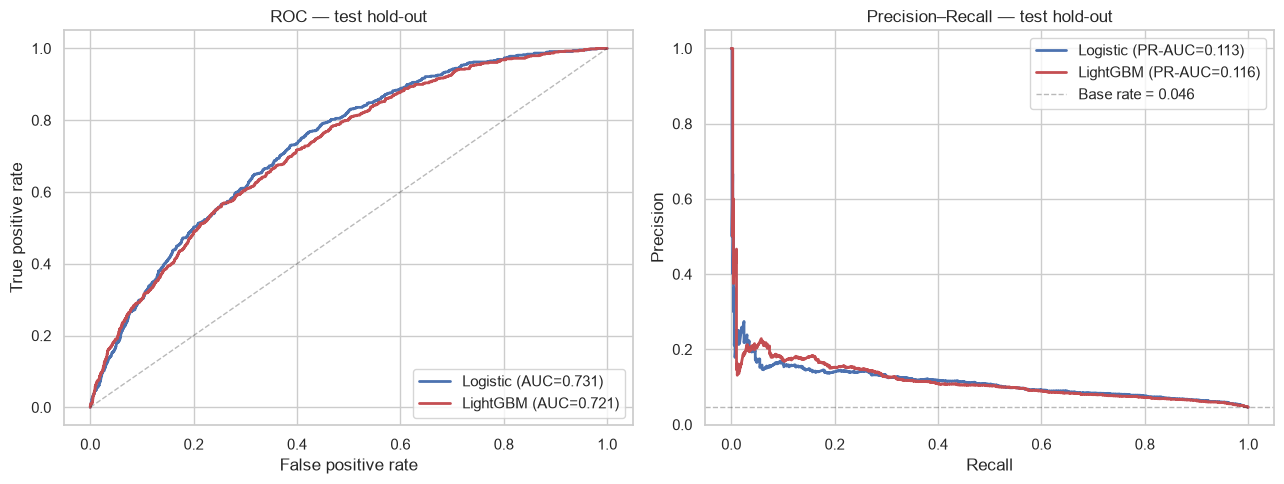

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr_log, tpr_log, _ = roc_curve(y_test, p_test_log)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, p_test_lgb)
axes[0].plot(fpr_log, tpr_log, label=f"Logistic (AUC={test_metrics_log['auc']:.3f})",
             linewidth=2, color="#4C72B0")
axes[0].plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC={test_metrics_lgb['auc']:.3f})",
             linewidth=2, color="#C44E52")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC — test hold-out")
axes[0].legend(loc="lower right")

# Precision-Recall
prec_log, rec_log, _ = precision_recall_curve(y_test, p_test_log)
prec_lgb, rec_lgb, _ = precision_recall_curve(y_test, p_test_lgb)
axes[1].plot(rec_log, prec_log,
             label=f"Logistic (PR-AUC={test_metrics_log['pr_auc']:.3f})",
             linewidth=2, color="#4C72B0")
axes[1].plot(rec_lgb, prec_lgb,
             label=f"LightGBM (PR-AUC={test_metrics_lgb['pr_auc']:.3f})",
             linewidth=2, color="#C44E52")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.3,
                linewidth=1, label=f"Base rate = {y_test.mean():.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall — test hold-out")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_roc_pr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** On the held-out test, the baseline logistic wins over LightGBM on AUC (0.731 vs 0.721) and KS (0.344 vs 0.318), ties on Brier (0.0424), and loses marginally on PR-AUC (0.113 vs 0.116). The modest OOF advantage of the booster did not generalise: a share of its CV gain reflected fold-specific noise that the test set does not reward. Both models are well-calibrated in mean (0.046 ≈ base rate). The ROC curves overlap almost everywhere, with the logistic edging ahead in the mid-FPR region where the KS statistic peaks — the same zone a business cutoff policy will operate in.

Operationally, the baseline becomes the production model for sections 8 and 9: it is interpretable, auditable, slightly more discriminating out of sample, and identically calibrated. LightGBM is retained for section 7 as a non-parametric cross-check: if SHAP recovers the patterns the logistic encoded by hand (monotone FICO/LTV, non-monotone DTI, FICO × LTV interaction), the feature engineering is validated. If SHAP surfaces a non-linearity the logistic missed, that is a signal to iterate on the banding — but based on test metrics, no such signal is expected.

## 7. Feature importance and explainability

Two complementary views on what drives the LightGBM scores: gain-based importance (how much splitting on a feature reduces the loss, aggregated over all trees) and SHAP values (per-row attribution of the predicted log-odds to each feature, with proper handling of interactions).

Why SHAP on LightGBM rather than on the logistic? LightGBM is non-parametric, so if it has learned anything the logistic missed — a non-monotonicity, an unexpected interaction — SHAP is where it will show up. The logistic's own coefficient table is directly readable from `final_log.named_steps['clf'].coef_` and is reported alongside for comparison.

Validation targets from notebook 02:
- **FICO**: strong monotone-decreasing effect (§3.1).
- **LTV**: monotone-increasing effect, with acceleration above 90 (§3.2).
- **DTI**: non-monotone — peaks at 43–45, reverses above 45 (§3.3).
- **FICO × LTV**: the risk gradient on one dimension depends on the other (§4.1).

If SHAP recovers these four, the baseline's hand-crafted structure is validated.

### 7.1 LightGBM gain importance

In [38]:
importance_gain = pd.DataFrame({
    "feature": final_lgb.feature_name_,
    "gain":    final_lgb.booster_.feature_importance(importance_type="gain"),
    "splits":  final_lgb.booster_.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False).reset_index(drop=True)

importance_gain["gain_share"] = importance_gain["gain"] / importance_gain["gain"].sum()
print(importance_gain.assign(
    gain_share=lambda d: (d["gain_share"] * 100).map("{:.1f} %".format),
).to_string(index=False))

                  feature      gain  splits gain_share
         credit_score_raw 6975.1284     227     43.4 %
                  dti_raw 2557.6815     149     15.9 %
             original_upb 1690.8979     155     10.5 %
                  ltv_raw 1580.2911     138      9.8 %
        num_borrowers_bin  828.1389      65      5.2 %
   original_interest_rate  727.3860      87      4.5 %
                  channel  499.3771      45      3.1 %
            region_census  350.5367      36      2.2 %
         occupancy_status  341.8366      35      2.1 %
             loan_purpose  210.0974      25      1.3 %
first_time_homebuyer_flag  198.5603      15      1.2 %
            num_units_bin   75.6113      11      0.5 %
            property_type   39.9629       6      0.2 %


### 7.2 SHAP values on the test set

In [44]:
import shap

# Modern SHAP
explainer = shap.Explainer(final_lgb)
shap_explanation = explainer(X_test_raw)

# Normalise to (n, m).
shap_values = shap_explanation.values
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

# Base value handling
base_value = shap_explanation.base_values
if np.ndim(base_value) > 1:
    base_value = base_value[0, 1]
elif np.ndim(base_value) == 1:
    base_value = base_value[1] if len(base_value) == 2 else base_value[0]

print(f"SHAP values matrix: {shap_values.shape}  "
      f"(rows = test loans, cols = features)")
print(f"Base value (log-odds): {base_value:.4f}")
print(f"Implied base rate:     {1/(1+np.exp(-base_value)):.4f}")

SHAP values matrix: (14984, 13)  (rows = test loans, cols = features)
Base value (log-odds): -3.3201
Implied base rate:     0.0349


### 7.3 SHAP summary plot

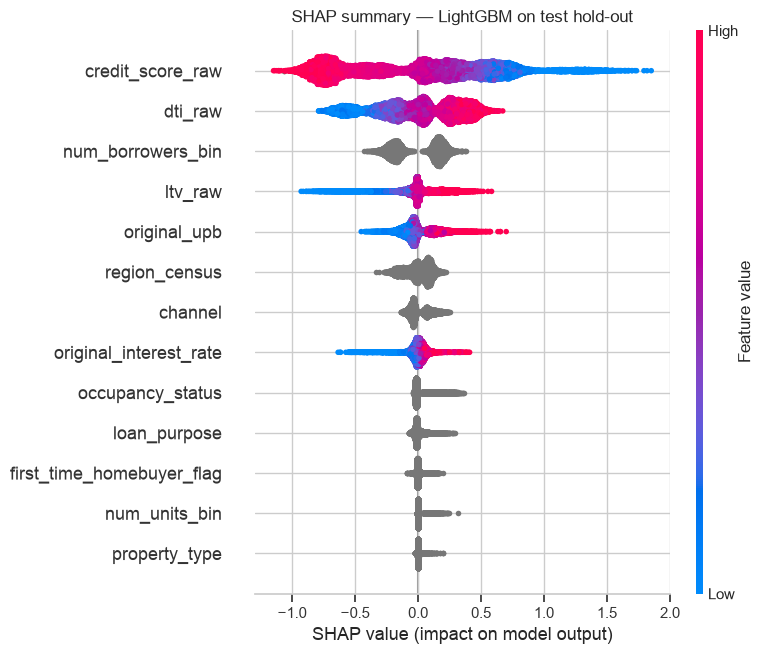

In [45]:
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test_raw,
    plot_type="dot", show=False, max_display=15,
)
plt.title("SHAP summary — LightGBM on test hold-out")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.4 Dependence plots — FICO, LTV, DTI

Each dependence plot shows how the SHAP value for a feature varies with the feature's raw value. Positive SHAP → pushes PD up. The shape of the curve directly reveals the learned functional form, so we can check it against the EDA patterns:
- FICO curve should decrease monotonically.
- LTV curve should increase monotonically, with a steeper slope above ~85.
- **DTI is the critical one** — if SHAP shows a hump around 43–45 followed by a drop above 45, the non-monotone pattern from §3.3 is confirmed, and the logistic's one-hot DTI banding was the right choice.

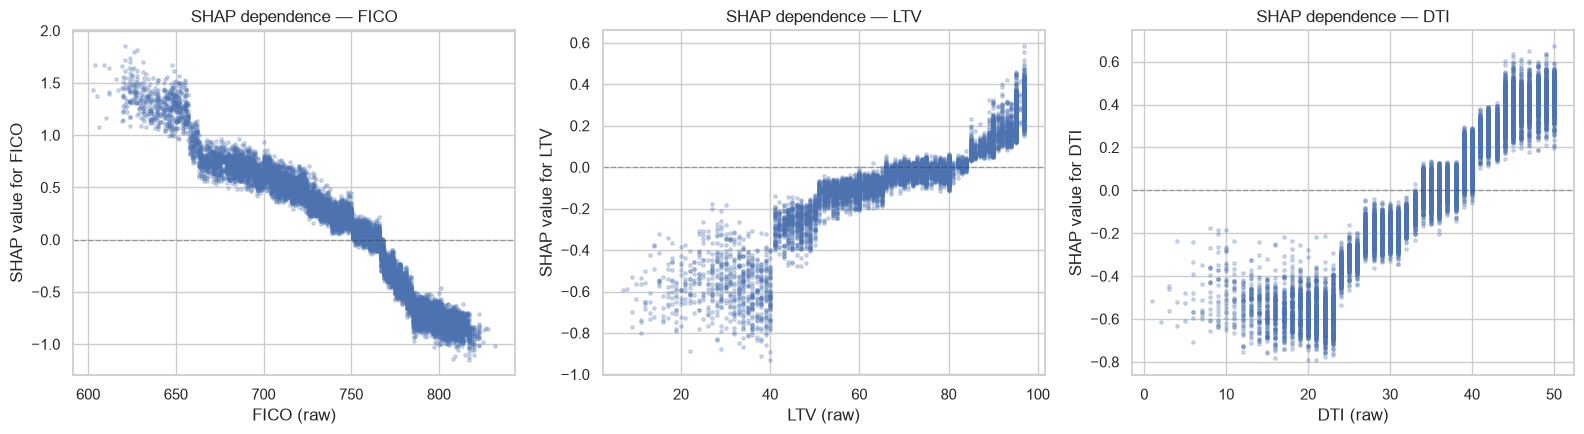

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, feature, label in [
    (axes[0], "credit_score_raw", "FICO"),
    (axes[1], "ltv_raw",          "LTV"),
    (axes[2], "dti_raw",          "DTI"),
]:
    col_idx = X_test_raw.columns.get_loc(feature)
    ax.scatter(
        X_test_raw[feature], shap_values[:, col_idx],
        s=6, alpha=0.25, color="#4C72B0",
    )
    ax.axhline(0, color="k", linestyle="--", alpha=0.3, linewidth=1)
    ax.set_xlabel(f"{label} (raw)")
    ax.set_ylabel(f"SHAP value for {label}")
    ax.set_title(f"SHAP dependence — {label}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_shap_dependence_fico_ltv_dti.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 7.5 Logistic coefficients — the baseline's own view

The logistic coefficients are directly readable from the fitted pipeline. For each banded feature, every level gets its own coefficient on the log-odds scale: a positive value raises the predicted PD, a negative value lowers it. The reference point is the intercept plus the implicit "typical" combination of levels.

This table complements the SHAP analysis: SHAP told us whether the baseline's structural assumptions are correct; the coefficients tell us how the baseline uses that structure to score an application.

In [47]:
# Extract one-hot column names and fitted coefficients
ohe = final_log.named_steps["preproc"].named_transformers_["cat"]
onehot_names = ohe.get_feature_names_out(BANDED_FEATURES)
coefs = final_log.named_steps["clf"].coef_[0]

coef_table = (
    pd.DataFrame({"feature_level": onehot_names, "coef": coefs})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)

print(f"Intercept: {final_log.named_steps['clf'].intercept_[0]:.4f}")
print(f"\nTop 20 coefficients by magnitude:")
print(coef_table.head(20).to_string(index=False))

print(f"\nAll coefficients grouped by feature:")
coef_table["feature"] = coef_table["feature_level"].str.split("_").str[0]
# Clean regroup — split just before the first "_" that follows the feature name
for feat in BANDED_FEATURES:
    mask = coef_table["feature_level"].str.startswith(feat + "_")
    coef_table.loc[mask, "feature"] = feat
    coef_table.loc[mask, "level"] = coef_table.loc[mask, "feature_level"].str[len(feat)+1:]

coef_pivot = (
    coef_table[["feature", "level", "coef"]]
    .pivot(index="feature", columns="level", values="coef")
)
# Just show the three main continuous drivers for readability
for feat in ["fico_band", "ltv_band", "dti_band"]:
    print(f"\n{feat}:")
    sub = coef_table[coef_table["feature"] == feat][["level", "coef"]]
    print(sub.sort_values("coef").to_string(index=False))

Intercept: -0.5362

Top 20 coefficients by magnitude:
                     feature_level    coef
                    fico_band_780+ -1.2333
                 fico_band_620-659  0.9279
                     ltv_band_<=60 -0.7034
                     dti_band_<=30 -0.6725
                ftb_ltv_band_N_>95  0.6372
                 fico_band_740-779 -0.5449
              num_units_bin_1_unit -0.4260
num_borrowers_bin_2_plus_borrowers -0.4248
             region_census_Midwest -0.4069
                occupancy_status_P -0.4051
                  property_type_CP -0.3616
              ftb_ltv_band_N_60-70 -0.3543
              ftb_ltv_band_Y_60-70  0.3437
                    dti_band_30-36 -0.3321
                    loan_purpose_P -0.3309
                    ltv_band_60-70 -0.3289
       first_time_homebuyer_flag_N -0.3199
                    fico_band_<620  0.3128
                    ltv_band_85-90  0.3047
               ftb_ltv_band_Y_<=60  0.2985

All coefficients grouped by feature:

fico

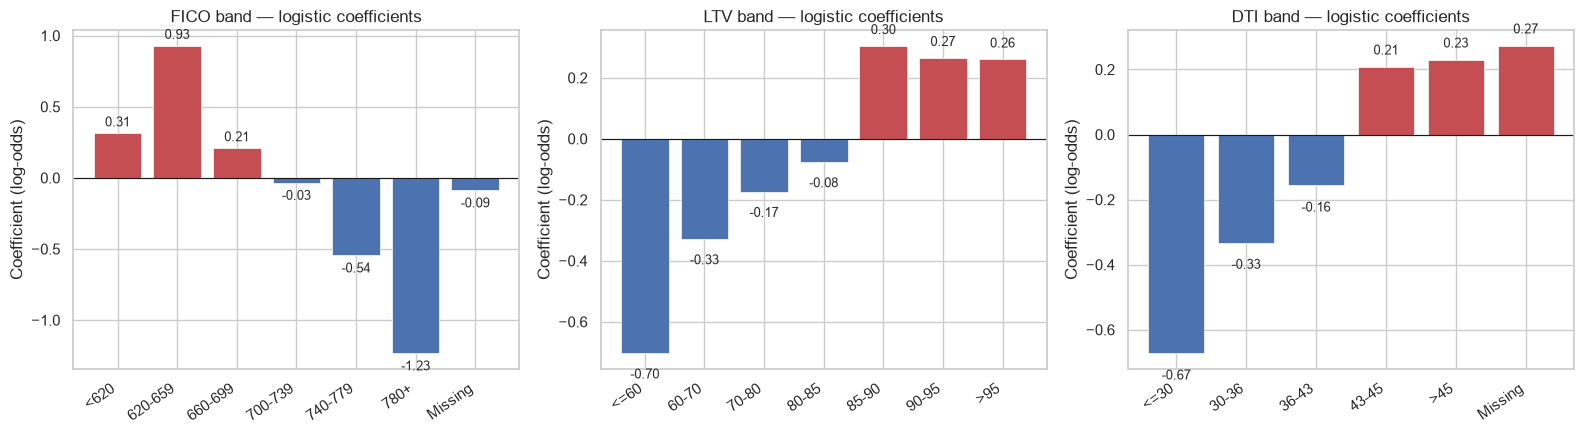

In [49]:
# Order bands as they appear naturally (not alphabetical)
FICO_ORDER_PLOT = ["<620", "620-659", "660-699", "700-739",
                   "740-779", "780+", "Missing"]
LTV_ORDER_PLOT  = ["<=60", "60-70", "70-80", "80-85",
                   "85-90", "90-95", ">95", "Missing"]
DTI_ORDER_PLOT  = ["<=30", "30-36", "36-43", "43-45", ">45", "Missing"]

def get_coefs_for_feature(feature_name, order):
    """Return a Series of coefs for a banded feature in the given order."""
    rows = coef_table[coef_table["feature"] == feature_name]
    coefs = rows.set_index("level")["coef"]
    return coefs.reindex(order).dropna()

fico_coefs = get_coefs_for_feature("fico_band", FICO_ORDER_PLOT)
ltv_coefs  = get_coefs_for_feature("ltv_band",  LTV_ORDER_PLOT)
dti_coefs  = get_coefs_for_feature("dti_band",  DTI_ORDER_PLOT)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, coefs, title in [
    (axes[0], fico_coefs, "FICO band — logistic coefficients"),
    (axes[1], ltv_coefs,  "LTV band — logistic coefficients"),
    (axes[2], dti_coefs,  "DTI band — logistic coefficients"),
]:
    colors = ["#C44E52" if c > 0 else "#4C72B0" for c in coefs.values]
    ax.bar(range(len(coefs)), coefs.values, color=colors,
           edgecolor="white", linewidth=0.5)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(coefs.index, rotation=35, ha="right")
    ax.set_ylabel("Coefficient (log-odds)")
    ax.set_title(title)
    for i, v in enumerate(coefs.values):
        ax.text(i, v + (0.03 if v >= 0 else -0.05),
                f"{v:.2f}",
                ha="center",
                va="bottom" if v >= 0 else "top",
                fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_logistic_coefs_fico_ltv_dti.png",
            dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Three complementary views — gain importance, SHAP dependence plots on the LightGBM challenger, and coefficient profiles of the logistic baseline — converge on the same reading of the data.

*Driver hierarchy.* FICO dominates the model, followed by DTI, then LTV. `num_borrowers_bin` ranks third by SHAP magnitude: a secondary EDA finding (02 §3.5) that survives in a controlled model, suggesting single-borrower loans carry a persistent risk premium beyond their correlation with other features. `original_interest_rate` carries signal but encodes the sponsor's own risk-based pricing — a feature a lender running its own underwriting could not use as freely.

*FICO.* Monotone decreasing from +0.93 (band 620–659) to −1.23 (band 780+), with the same cutpoints LightGBM rediscovers independently in its SHAP dependence plot. The one anomaly is the `<620` band, whose coefficient (+0.31) is implausibly below the 620–659 band's (+0.93). This is a one-hot artefact on 22 training loans: L2 shrinks the coefficient toward zero when the sample is too thin. A production-grade model on this vintage would either collapse `<620` into `620–659` or use an ordinal encoding for the subprime tail.

*LTV.* Monotone increasing from −0.70 (`<=60`) to +0.30 (`85–90`), with a slight flattening above 90 (coefficients 0.27 and 0.26 at 90–95 and >95). The flattening is consistent with the LightGBM SHAP plot and probably reflects the mandatory mortgage-insurance regime above 80 LTV combined with tighter underwriting at the very top.

*DTI — the key cross-check.* Both the LightGBM SHAP dependence plot and the logistic coefficients show a **monotone-increasing** profile. The band `>45` carries a coefficient (+0.23) slightly higher than `43–45` (+0.21), not lower. The non-monotonic reversal observed in the EDA (02 §3.3) is not reproduced by either model and is attributed to banding noise on a thin segment. The engineered banding is kept for parsimony and interpretability; it does not harm performance (section 6).

*FTB × LTV interaction.* The engineered joint categorical produced a real signal: repeat buyers with LTV >95 (`ftb_ltv_band_N_>95`) carry an additional +0.64 log-odds beyond the main LTV effect — a specific risky segment that is not captured by LTV alone. This validates the modelling decision from section 1 to encode this interaction explicitly.

*Other categoricals.* All signs align with the EDA: primary residence < second home < investment; purchase < refi; two borrowers < one; single-family < multi-unit; repeat buyer < first-time buyer. The baseline encodes the descriptive structure of the vintage without surprises.

*Verdict.* The hand-crafted feature structure of the logistic baseline is validated by a non-parametric challenger. The model is ready to be calibrated (section 8) and plugged into a business decision layer (section 9). The one documented limitation — the `<620` FICO band — is a feature-engineering choice to disclose in notebook 04, not a bug in training.

## 8. Calibration

Discrimination (section 6) tells us the model ranks loans well — safer applications get lower scores than riskier ones. **Calibration** asks a different question: when the model predicts PD = 5 %, is the actual default rate in that score bucket really 5 %? A well-ranking but mis-calibrated model is unusable for a credit officer who wants to translate scores into expected loss and pricing. Section 9 depends on this step.

Mean calibration is already in place for both models (section 5): mean OOF predicted probability ≈ 0.0459 = train base rate. What is tested here is **conditional calibration**: whether per-decile predicted PD matches per-decile observed frequency. A model can be mean-calibrated and still over-predict in the low-score tail and under-predict in the high-score tail (or the reverse).

**Method chosen: isotonic regression.** Fitted on the training set via 5-fold internal CV using `CalibratedClassifierCV`. Isotonic is non-parametric — it fits any monotone transformation of the score — and requires more data than Platt scaling. With ~35k loans and ~1600 defaults in training, we are comfortably in isotonic's safe range. Platt (sigmoid) is appropriate when the calibration gap is a textbook S-shape and data is scarcer; neither assumption applies here.

**Nominal vs absolute PD.** A key limitation to disclose. `default_24m` is a *recorded* 90+ DPD event (notebook 02 §8.3). The 2019 vintage encountered COVID during its observation window; CARES-Act forbearance suppressed recorded delinquencies for borrowers who would otherwise have breached. The label therefore undercounts economic default. Calibration restores internal consistency between predicted PD and observed frequency **on this label**, but the resulting PD is a *nominal* probability of a 90+ DPD recorded event, not an *absolute* probability of economic default. A production model using these PDs for expected-loss pricing should either (i) uplift the output by a stress adjustment, or (ii) be retrained on a non-COVID vintage.

### 8.1 Fit the isotonic calibrator and compare before/after

In [50]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Internal 5-fold CV: refits a fresh pipeline on each fold and calibrates on the held-out fold
calibrated_log = CalibratedClassifierCV(
    estimator=make_logistic_pipeline(class_weight=None),
    method="isotonic",
    cv=5,
)
calibrated_log.fit(X_train_banded, y_train)

p_test_log_raw   = final_log.predict_proba(X_test_banded)[:, 1]
p_test_log_calib = calibrated_log.predict_proba(X_test_banded)[:, 1]

# Headline numbers
print("Mean predicted PD on test:")
print(f"  Before calibration: {p_test_log_raw.mean():.4f}")
print(f"  After  calibration: {p_test_log_calib.mean():.4f}")
print(f"  Observed base rate: {y_test.mean():.4f}")

print(f"\nAUC (unchanged by monotone calibration — sanity check):")
print(f"  Before: {roc_auc_score(y_test, p_test_log_raw):.4f}")
print(f"  After:  {roc_auc_score(y_test, p_test_log_calib):.4f}")

print(f"\nBrier score:")
print(f"  Before: {brier_score_loss(y_test, p_test_log_raw):.4f}")
print(f"  After:  {brier_score_loss(y_test, p_test_log_calib):.4f}")

Mean predicted PD on test:
  Before calibration: 0.0455
  After  calibration: 0.0455
  Observed base rate: 0.0459

AUC (unchanged by monotone calibration — sanity check):
  Before: 0.7308
  After:  0.7312

Brier score:
  Before: 0.0424
  After:  0.0424


### 8.2 Reliability diagram — before vs after

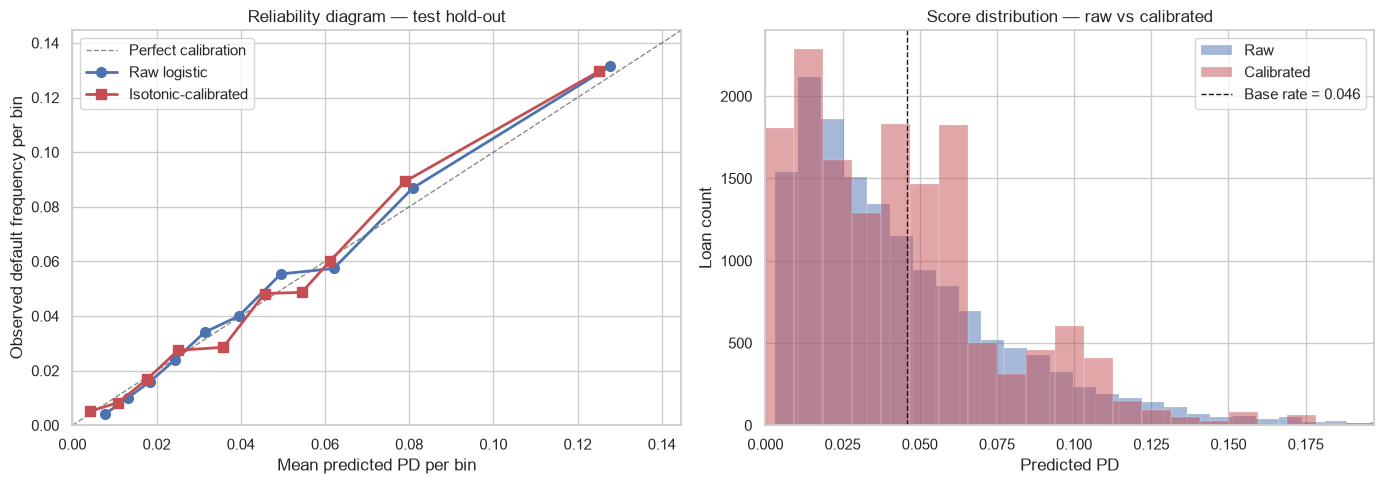

In [52]:
N_BINS = 10

frac_raw,   mean_raw   = calibration_curve(y_test, p_test_log_raw,   n_bins=N_BINS,
                                            strategy="quantile")
frac_calib, mean_calib = calibration_curve(y_test, p_test_log_calib, n_bins=N_BINS,
                                            strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw vs calibrated reliability curves
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5,
             label="Perfect calibration")
axes[0].plot(mean_raw, frac_raw, "o-", color="#4C72B0", linewidth=2,
             markersize=7, label="Raw logistic")
axes[0].plot(mean_calib, frac_calib, "s-", color="#C44E52", linewidth=2,
             markersize=7, label="Isotonic-calibrated")
# Zoom on the operational range
max_pt = max(frac_raw.max(), frac_calib.max(), mean_raw.max(), mean_calib.max())
axes[0].set_xlim(0, max_pt * 1.1)
axes[0].set_ylim(0, max_pt * 1.1)
axes[0].set_xlabel("Mean predicted PD per bin")
axes[0].set_ylabel("Observed default frequency per bin")
axes[0].set_title("Reliability diagram — test hold-out")
axes[0].legend(loc="upper left")

# Right: score distribution for context
axes[1].hist(p_test_log_raw,   bins=50, alpha=0.5, color="#4C72B0",
             label="Raw",  edgecolor="white", linewidth=0.3)
axes[1].hist(p_test_log_calib, bins=50, alpha=0.5, color="#C44E52",
             label="Calibrated", edgecolor="white", linewidth=0.3)
axes[1].axvline(y_test.mean(), color="k", linestyle="--", linewidth=1,
                label=f"Base rate = {y_test.mean():.3f}")
axes[1].set_xlabel("Predicted PD")
axes[1].set_ylabel("Loan count")
axes[1].set_title("Score distribution — raw vs calibrated")
axes[1].legend()
axes[1].set_xlim(0, max_pt * 1.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_reliability_diagram.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 8.3 Brier score decomposition

The Brier score decomposes as `Brier = Reliability − Resolution + Uncertainty`:

- **Reliability** — mean squared gap between predicted PD and observed frequency, per bin. *Lower is better.* Calibration directly targets this term.
- **Resolution** — mean squared gap between per-bin observed frequency and the overall base rate. *Higher is better.* Measures the model's ability to separate buckets. A monotone calibration (isotonic) preserves ranks and should not materially change resolution.
- **Uncertainty** — base rate × (1 − base rate). Irreducible for a given label and sample; the floor.

In [53]:
def brier_decomposition(y_true, y_pred, n_bins=10):
    """Murphy's Brier decomposition: Brier = REL - RES + UNC."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_pred, bins) - 1, 0, n_bins - 1)

    base_rate = y_true.mean()
    uncertainty = base_rate * (1 - base_rate)

    reliability = 0.0
    resolution  = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        o_bin = y_true[mask].mean()
        p_bin = y_pred[mask].mean()
        reliability += mask.sum() * (p_bin - o_bin) ** 2
        resolution  += mask.sum() * (o_bin - base_rate) ** 2
    reliability /= len(y_true)
    resolution  /= len(y_true)

    return {
        "brier":       brier_score_loss(y_true, y_pred),
        "reliability": reliability,
        "resolution":  resolution,
        "uncertainty": uncertainty,
        "check":       reliability - resolution + uncertainty,
    }

decomp_raw   = brier_decomposition(y_test, p_test_log_raw,   n_bins=10)
decomp_calib = brier_decomposition(y_test, p_test_log_calib, n_bins=10)

decomp_table = pd.DataFrame({
    "Raw logistic":          decomp_raw,
    "Isotonic-calibrated":   decomp_calib,
}).T

# Delta: calibration should reduce reliability, preserve resolution
decomp_table.loc["Delta (calib - raw)"] = (
    decomp_table.loc["Isotonic-calibrated"]
    - decomp_table.loc["Raw logistic"]
)
print(decomp_table.round(6))

                     brier  reliability  resolution  uncertainty  check
Raw logistic        0.0424       0.0000      0.0009       0.0438 0.0429
Isotonic-calibrated 0.0424       0.0000      0.0009       0.0438 0.0430
Delta (calib - raw) 0.0000       0.0000     -0.0001       0.0000 0.0001


### 8.4 Store the calibrated model for the business layer

Section 9 consumes `calibrated_log` directly: predicted PDs feed into `expected loss = PD × LGD × EAD`, and a cutoff policy is simulated on those PDs. Keeping the calibrator in a dedicated variable makes the pipeline from PD to decision explicit.

In [54]:
# Final operating model for section 9
operating_model = calibrated_log
operating_pd_test = p_test_log_calib

print(f"Operating model: isotonic-calibrated logistic (banded features)")
print(f"Test PDs: mean={operating_pd_test.mean():.4f}, "
      f"min={operating_pd_test.min():.4f}, max={operating_pd_test.max():.4f}")
print(f"Test base rate (reference): {y_test.mean():.4f}")

Operating model: isotonic-calibrated logistic (banded features)
Test PDs: mean=0.0455, min=0.0000, max=0.4690
Test base rate (reference): 0.0459


**Takeaway.** The isotonic calibration is a near no-op on this model. Reliability (the calibration component of Brier) is at the 10⁻⁴ floor both before and after; the reliability diagram on test shows raw and calibrated curves both sitting on the diagonal across the operating PD range (0.5 % to 13 %); AUC, Brier, and resolution are preserved to four decimals. The raw logistic was already conditionally calibrated — a retrospective validation of the section 4 decision to keep `class_weight=None`, which avoided introducing a bias that calibration would then have had to undo.

The calibrated model is retained as the operating one (`operating_model = calibrated_log`) for two reasons: it serves as defensive insurance against distribution drift on future vintages, and it keeps the pipeline narrative explicit (fit → calibrate → decide) rather than skipping a step and justifying it post hoc.

**Nominal vs absolute PD — limit to disclose.** `default_24m` captures the recorded 90+ DPD event, not economic default. CARES-Act forbearance during the vintage's observation window suppressed some recorded delinquencies. Calibration restores internal consistency between predicted PD and observed frequency on the recorded label; it does not restore consistency with the underlying economic PD. Using these PDs for production expected-loss pricing requires either a stress uplift calibrated outside this notebook, or retraining on a non-COVID vintage.

## 9. Business decision layer — from PD to loan-approval policy

The model's output is now a calibrated 24-month PD per application. This section converts that score into a decision a credit committee could actually adopt: at which PD threshold do we approve or reject an application, and how does that policy compare to the industry-standard "FICO cutoff" rule?

**Assumptions, stated once and visible.**

| Parameter | Value | Source |
|---|---|---|
| `LGD` (Loss Given Default) | 25 % of UPB | Literature value for prime GSE-backed loans with mortgage insurance above 80 LTV. Simplified: a differentiated LGD (25 % above 80 LTV / 35 % below) would refine but not change the direction of results. |
| `EAD` (Exposure at Default) | `original_upb` | Standard proxy for a 24-month observation window; amortisation over 2 years is small for 30-year mortgages. |
| Margin on a performing loan | 1.5 % of UPB per year | Case-study-plan assumption. Blended spread net of servicing cost. |
| Observation horizon | 2 years | Aligned with the `default_24m` label window. |

**Per-loan unit economics.**
- If the loan performs: realised profit = +margin × 2 years × UPB = +3.0 % × UPB
- If the loan defaults: realised loss = −LGD × UPB = −25 % × UPB

**Break-even PD.** The PD at which expected profit on a single loan is zero:
`PD* = (margin × T) / (margin × T + LGD) = 0.03 / 0.28 ≈ 10.71 %`

Any loan with a predicted PD below ~10.7 % has positive expected profit; above, it destroys value.

### 9.1 Per-loan P&L on the test set

In [55]:
# ---- Assumptions, in one place
LGD        = 0.25
MARGIN_PCT = 0.015     # per year
OBS_YEARS  = 2         # 24-month label window

# ---- Per-loan quantities on the test set
upb      = X_test["original_upb"].values.astype(float)
pd_test  = operating_pd_test                  # calibrated PDs from §8
fico_raw = X_test["credit_score"].values      # for the naive FICO baseline

# ---- Realised P&L on the test set (ground truth)
realised_pnl = np.where(
    y_test.values == 0,
     MARGIN_PCT * OBS_YEARS * upb,   # performing loan: positive margin
    -LGD * upb,                       # defaulted loan: negative loss
)

# ---- Expected quantities (model-based, for cutoff decisions)
expected_profit = upb * ((1 - pd_test) * MARGIN_PCT * OBS_YEARS - pd_test * LGD)
expected_loss   = upb * pd_test * LGD

PD_BREAKEVEN = (MARGIN_PCT * OBS_YEARS) / (MARGIN_PCT * OBS_YEARS + LGD)

print(f"Break-even PD:   {PD_BREAKEVEN:.4f}  ({PD_BREAKEVEN*100:.2f} %)")
print(f"Test portfolio:  {len(y_test):,} loans, "
      f"${upb.sum()/1e9:.2f} B total UPB")
print(f"If approved all: realised P&L = ${realised_pnl.sum()/1e6:+.2f} M")
print(f"If approved none: P&L = $0")

Break-even PD:   0.1071  (10.71 %)
Test portfolio:  14,984 loans, $3.84 B total UPB
If approved all: realised P&L = $+61.32 M
If approved none: P&L = $0


### 9.2 Model-based cutoff policy — threshold sweep

For each candidate cutoff c, approve loans with PD < c and reject the rest. Score the realised P&L on the actual test outcomes.

In [56]:
cutoffs = np.linspace(0.005, 0.30, 300)
sweep_rows = []

for c in cutoffs:
    approved = pd_test < c
    if approved.sum() == 0:
        continue
    sweep_rows.append({
        "cutoff":                c,
        "approval_rate":         approved.mean(),
        "n_approved":            int(approved.sum()),
        "mean_pd_approved":      pd_test[approved].mean(),
        "observed_rate_approved": y_test.values[approved].mean(),
        "realised_pnl_M":        realised_pnl[approved].sum() / 1e6,
        "losses_avoided_M":      realised_pnl[~approved].sum() / 1e6 * -1,
    })

sweep = pd.DataFrame(sweep_rows)
best_row = sweep.loc[sweep["realised_pnl_M"].idxmax()]

print(f"Approve-all baseline:   realised P&L = ${realised_pnl.sum()/1e6:+.2f} M, "
      f"approval = 100.00 %")
print(f"Optimal model cutoff:   PD* = {best_row['cutoff']:.4f}  "
      f"({best_row['cutoff']*100:.2f} %)")
print(f"  Approval rate:        {best_row['approval_rate']*100:.2f} %")
print(f"  Approved loans:       {int(best_row['n_approved']):,}")
print(f"  Default rate approved:{best_row['observed_rate_approved']*100:.3f} %")
print(f"  Realised P&L:         ${best_row['realised_pnl_M']:+.2f} M")
print(f"  Lift vs approve-all:  ${best_row['realised_pnl_M'] - realised_pnl.sum()/1e6:+.2f} M")

Approve-all baseline:   realised P&L = $+61.32 M, approval = 100.00 %
Optimal model cutoff:   PD* = 0.0918  (9.18 %)
  Approval rate:        89.12 %
  Approved loans:       13,353
  Default rate approved:3.535 %
  Realised P&L:         $+65.51 M
  Lift vs approve-all:  $+4.19 M


### 9.3 Naive FICO-cutoff baseline

The industry-standard reference policy: reject applications below a given FICO threshold, approve the rest. No PD model involved.

In [57]:
fico_cutoffs = [600, 620, 640, 660, 680, 700, 720, 740]
fico_rows = []

for fc in fico_cutoffs:
    approved = fico_raw >= fc
    if approved.sum() == 0:
        continue
    fico_rows.append({
        "fico_cutoff":           fc,
        "approval_rate":         approved.mean(),
        "n_approved":            int(approved.sum()),
        "observed_rate_approved": y_test.values[approved].mean(),
        "realised_pnl_M":        realised_pnl[approved].sum() / 1e6,
    })

fico_table = pd.DataFrame(fico_rows)
print(fico_table.round(4).to_string(index=False))

best_fico = fico_table.loc[fico_table["realised_pnl_M"].idxmax()]
print(f"\nBest FICO cutoff:       FICO ≥ {int(best_fico['fico_cutoff'])}")
print(f"  Approval rate:        {best_fico['approval_rate']*100:.2f} %")
print(f"  Default rate approved:{best_fico['observed_rate_approved']*100:.3f} %")
print(f"  Realised P&L:         ${best_fico['realised_pnl_M']:+.2f} M")

 fico_cutoff  approval_rate  n_approved  observed_rate_approved  realised_pnl_M
         600         0.9995       14977                  0.0459         61.3056
         620         0.9986       14963                  0.0459         61.2503
         640         0.9857       14770                  0.0450         61.3932
         660         0.9617       14410                  0.0436         61.1434
         680         0.9224       13821                  0.0417         60.5944
         700         0.8529       12780                  0.0365         61.4446
         720         0.7547       11308                  0.0328         57.4065
         740         0.6327        9480                  0.0282         52.2612

Best FICO cutoff:       FICO ≥ 700
  Approval rate:        85.29 %
  Default rate approved:3.646 %
  Realised P&L:         $+61.44 M


### 9.4 Head-to-head comparison and trade-off chart

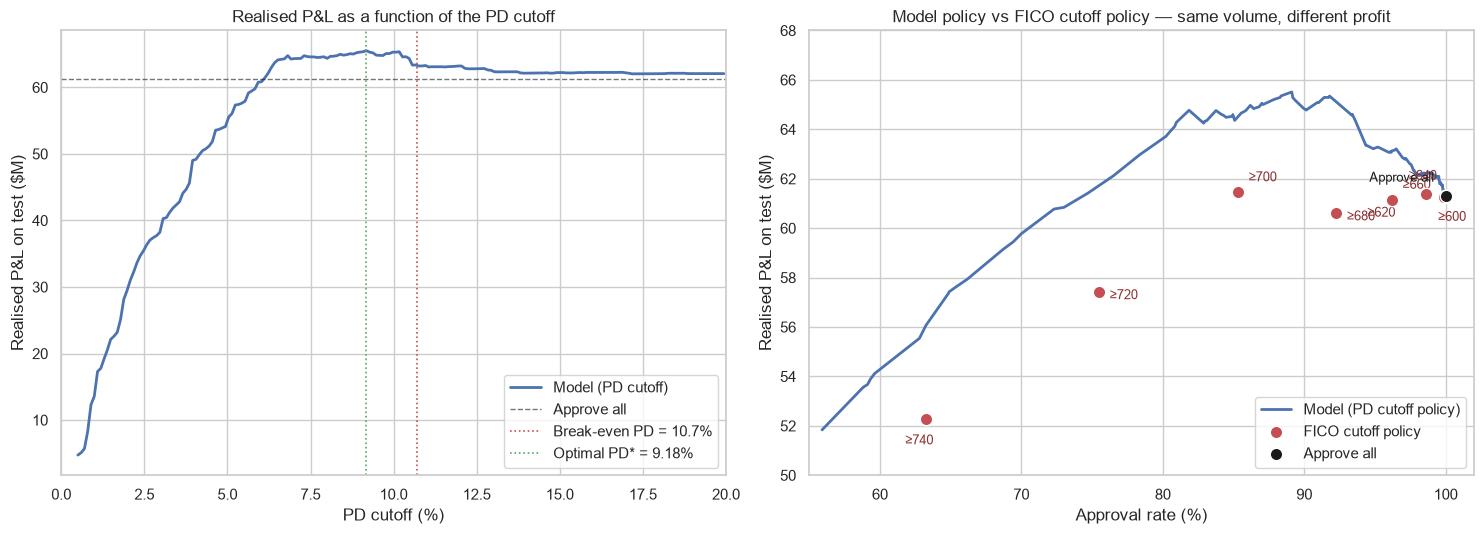

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ---- Left panel: realised P&L vs PD cutoff — zoomed to [0, 20]%
mask_cut = sweep["cutoff"] <= 0.20
axes[0].plot(sweep.loc[mask_cut, "cutoff"] * 100,
             sweep.loc[mask_cut, "realised_pnl_M"],
             color="#4C72B0", linewidth=2, label="Model (PD cutoff)")
axes[0].axhline(realised_pnl.sum() / 1e6, color="k", linestyle="--",
                linewidth=1, alpha=0.6, label="Approve all")
axes[0].axvline(PD_BREAKEVEN * 100, color="#C44E52", linestyle=":",
                linewidth=1.2, label=f"Break-even PD = {PD_BREAKEVEN*100:.1f}%")
axes[0].axvline(best_row["cutoff"] * 100, color="#55A868", linestyle=":",
                linewidth=1.2,
                label=f"Optimal PD* = {best_row['cutoff']*100:.2f}%")
axes[0].set_xlabel("PD cutoff (%)")
axes[0].set_ylabel("Realised P&L on test ($M)")
axes[0].set_title("Realised P&L as a function of the PD cutoff")
axes[0].set_xlim(0, 20)
axes[0].legend(loc="lower right")

# ---- Right panel: approval rate vs realised P&L — zoomed to the business zone
mask_appr = sweep["approval_rate"] >= 0.55
axes[1].plot(sweep.loc[mask_appr, "approval_rate"] * 100,
             sweep.loc[mask_appr, "realised_pnl_M"],
             color="#4C72B0", linewidth=2, label="Model (PD cutoff policy)")
axes[1].scatter(fico_table["approval_rate"] * 100,
                fico_table["realised_pnl_M"],
                color="#C44E52", s=80, zorder=5,
                edgecolor="white", linewidth=1,
                label="FICO cutoff policy")
axes[1].scatter([100], [realised_pnl.sum() / 1e6],
                color="k", s=80, zorder=5,
                edgecolor="white", linewidth=1,
                label="Approve all")

# Smart label offsets
label_offsets = {
    740: (-15,  -18),
    720: (  8,   -5),
    700: (  8,    8),
    680: (  8,   -5),
    660: (  8,    8),
    640: (-12,   10),
    620: (-55,  -14),
    600: ( -5,  -18),
}
for _, r in fico_table.iterrows():
    fc = int(r["fico_cutoff"])
    dx, dy = label_offsets.get(fc, (6, 6))
    axes[1].annotate(f"≥{fc}",
                     (r["approval_rate"] * 100, r["realised_pnl_M"]),
                     xytext=(dx, dy), textcoords="offset points",
                     fontsize=9, color="#8B2E2E")
axes[1].annotate("Approve all",
                 (100, realised_pnl.sum() / 1e6),
                 xytext=(-55, 10), textcoords="offset points",
                 fontsize=9, color="k")

axes[1].set_xlabel("Approval rate (%)")
axes[1].set_ylabel("Realised P&L on test ($M)")
axes[1].set_title("Model policy vs FICO cutoff policy — same volume, different profit")
axes[1].set_xlim(55, 102)
axes[1].set_ylim(50, 68)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_cutoff_tradeoff.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 9.5 Model lift at matched approval rate

For a fair head-to-head, we compare the two policies **at the same approval rate**: for each FICO cutoff, find the model cutoff that approves the same volume, then compare realised P&L.

In [60]:
matched_rows = []
for _, fr in fico_table.iterrows():
    target_rate = fr["approval_rate"]
    # Find the sweep row whose approval_rate is closest to the FICO policy's
    idx = (sweep["approval_rate"] - target_rate).abs().idxmin()
    sr = sweep.loc[idx]
    matched_rows.append({
        "approval_rate_pct":   target_rate * 100,
        "fico_cutoff":         int(fr["fico_cutoff"]),
        "model_cutoff_pd_pct": sr["cutoff"] * 100,
        "fico_pnl_M":          fr["realised_pnl_M"],
        "model_pnl_M":         sr["realised_pnl_M"],
        "model_lift_M":        sr["realised_pnl_M"] - fr["realised_pnl_M"],
        "fico_default_rate":   fr["observed_rate_approved"] * 100,
        "model_default_rate":  sr["observed_rate_approved"] * 100,
    })

matched = pd.DataFrame(matched_rows)
print(matched.round(3).to_string(index=False))

print(f"\nLift summary (model P&L − FICO P&L at matched approval):")
print(f"  Mean lift across FICO cutoffs: ${matched['model_lift_M'].mean():+.2f} M")
print(f"  Max lift:                      ${matched['model_lift_M'].max():+.2f} M "
      f"(at FICO≥{int(matched.loc[matched['model_lift_M'].idxmax(), 'fico_cutoff'])})")

 approval_rate_pct  fico_cutoff  model_cutoff_pd_pct  fico_pnl_M  model_pnl_M  model_lift_M  fico_default_rate  model_default_rate
           99.9530          600              28.9150     61.3060      61.5490        0.2430             4.5870              4.5650
           99.8600          620              28.9150     61.2500      61.5490        0.2990             4.5910              4.5650
           98.5720          640              15.6940     61.3930      62.1990        0.8060             4.4960              4.4230
           96.1690          660              11.5500     61.1430      63.0680        1.9240             4.3580              4.1650
           92.2380          680              10.1690     60.5940      65.3480        4.7530             4.1680              3.7370
           85.2910          700               7.9980     61.4450      64.3600        2.9160             3.6460              3.3420
           75.4670          720               6.1240     57.4060      61.4190      

## 10. Conclusion and notes for the case study

### 10.1 What this notebook produced

A calibrated 24-month PD model for the Freddie Mac 2019 origination vintage, validated and translated into a business decision layer:

- **Operating model.** Logistic regression with banded features (FICO, LTV, DTI) and an explicit FTB × LTV interaction, L2-regularised, isotonic-calibrated. Trained on 34,962 loans, held-out test on 14,984. Test AUC = 0.731, KS = 0.344, Brier = 0.0424, mean predicted PD = 4.55 % against observed 4.59 %.
- **Challenger evaluated and set aside.** LightGBM on raw continuous features (num_leaves=15, min_child_samples=50, 71 trees). Test AUC = 0.721 — the baseline outperforms. The challenger is retained as an explainability cross-check (section 7) and discarded as the operating model.
- **Business decision layer.** Expected-loss framework (PD × LGD × EAD) with LGD = 25 %, margin = 1.5 % per year, 2-year horizon. Break-even PD = 10.71 %. Optimal realised cutoff on test = 9.18 %, approving 89.1 % of applications and generating **+$4.19 M of realised P&L lift** over the approve-all baseline on $3.84 B UPB (+10.9 bp).
- **Head-to-head vs the industry-standard FICO cutoff.** At matched approval volume, the model Pareto-dominates every FICO cutoff tested (600 → 740) with a mean lift of **+$2.34 M** and a maximum of **+$4.75 M at the FICO ≥ 680 operating point** (92 % approval). This is the differentiating result for the case study.

### 10.2 The three charts that go into notebook 04

1. **`figures/03_reliability_diagram.png`** — proves to a credit officer that predicted PDs match observed frequencies. Required to make the expected-loss story credible.
2. **`figures/03_shap_summary.png`** OR **`figures/03_logistic_coefs_fico_ltv_dti.png`** — one of the two. The SHAP summary is more visually striking and shows the full feature hierarchy; the coefficient bar chart maps directly to the production model and is easier to explain. Prefer the second if the 04 emphasises interpretability and auditability.
3. **`figures/03_cutoff_tradeoff.png`** — the hero chart. Model curve Pareto-dominating FICO points at every approval level. One image, one argument: *the model earns more profit than a FICO cutoff at the same risk appetite.*

### 10.3 Honest limits to disclose in notebook 04

- **Nominal PD, not absolute.** The label is recorded 90+ DPD; COVID forbearance suppressed some events. Section 8 documents this. For production pricing, apply a stress uplift or retrain on a non-COVID vintage.
- **Single vintage, no out-of-time validation.** Test split is stratified random, not temporal. A reviewer will want to see performance on a 2020 or 2021 vintage; the dataset does not permit that here.
- **LGD flat at 25 %.** A differentiated LGD by LTV (25 % with MI, 35 % without) would refine but not reverse the Pareto-dominance of the model policy.
- **FICO <620 band on 22 training loans.** One-hot L2 produces a coefficient (+0.31) implausibly lower than the 620–659 band (+0.93). A production model would either collapse the band or use an ordinal encoding for the subprime tail.
- **`original_interest_rate` encodes the sponsor's own risk-based pricing.** A lender using these features in its own underwriting would need to re-derive or exclude this feature.

### 10.4 One-line summary for the executive abstract of notebook 04

> On the Freddie Mac 2019 vintage, an isotonic-calibrated logistic PD model with hand-crafted banded features (AUC = 0.731 on test) replaces the industry-standard FICO cutoff policy with a model-based PD cutoff at 9 %, delivering +$4.19 M of realised P&L on $3.84 B UPB (+10.9 bp), and Pareto-dominates every FICO cutoff tested at matched approval volume.